In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import json

In [2]:
df=pd.read_csv("../SGJobData.csv")

In [3]:
df.describe()

,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,minimumYearsExperience,numberOfVacancies,occupationId,salary_maximum,salary_minimum,status_id,average_salary
count,1.048585e+06,1.048585e+06,1.048585e+06,1.048585e+06,1.048585e+06,0.0,1.048585e+06,1.048585e+06,1048585.0,1.048585e+06
mean,5.472327e-02,2.136571e+00,2.674536e+01,2.779573e+00,2.680043e+00,NaN,5.723578e+03,3.815312e+03,0.0,4.769445e+03
std,2.822675e-01,1.062612e+01,8.262001e+01,2.537049e+00,1.124301e+01,NaN,5.018387e+04,3.172182e+03,0.0,2.547809e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.0,0.000000e+00
25%,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,NaN,3.300000e+03,2.500000e+03,0.0,2.900000e+03
50%,0.000000e+00,0.000000e+00,4.000000e+00,2.000000e+00,1.000000e+00,NaN,4.500000e+03,3.000000e+03,0.0,3.800000e+03
75%,0.000000e+00,1.000000e+00,1.700000e+01,4.000000e+00,2.000000e+00,NaN,6.500000e+03,4.500000e+03,0.0,5.500000e+03
max,2.000000e+00,1.342000e+03,8.190000e+03,8.800000e+01,9.990000e+02,NaN,2.533000e+07,3.500000e+05,0.0,1.266640e+07


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048585 entries, 0 to 1048584
Data columns (total 22 columns):
 #   Column                              Non-Null Count    Dtype  
---  ------                              --------------    -----  
 0   categories                          1044597 non-null  str    
 1   employmentTypes                     1044597 non-null  str    
 2   metadata_expiryDate                 1044597 non-null  str    
 3   metadata_isPostedOnBehalf           1048585 non-null  bool   
 4   metadata_jobPostId                  1044597 non-null  str    
 5   metadata_newPostingDate             1044597 non-null  str    
 6   metadata_originalPostingDate        1044597 non-null  str    
 7   metadata_repostCount                1048585 non-null  int64  
 8   metadata_totalNumberJobApplication  1048585 non-null  int64  
 9   metadata_totalNumberOfView          1048585 non-null  int64  
 10  minimumYearsExperience              1048585 non-null  int64  
 11  numberOfVacancies     

In [5]:
df.shape

(1048585, 22)

In [6]:
#2. Drop Null values AND Occupation ID from dataset 

print("===== Display nulls values ====")
print()
print(df.isnull().sum())
print()
df1=df.drop(columns=['occupationId'])
df1=df1[df1['categories'].notnull()]

# Drop nulls for 
print("===== Removal of nulls values ====")
print()
print(df1.isnull().sum())
print(df1.shape)

===== Display nulls values ====

categories                               3988
employmentTypes                          3988
metadata_expiryDate                      3988
metadata_isPostedOnBehalf                   0
metadata_jobPostId                       3988
metadata_newPostingDate                  3988
metadata_originalPostingDate             3988
metadata_repostCount                        0
metadata_totalNumberJobApplication          0
metadata_totalNumberOfView                  0
minimumYearsExperience                      0
numberOfVacancies                           0
occupationId                          1048585
positionLevels                           3988
postedCompany_name                       3988
salary_maximum                              0
salary_minimum                              0
salary_type                              3988
status_id                                   0
status_jobStatus                         3988
title                                    3988
a

In [7]:
#3.1 Identity data period in dataset

data_time1 = df1[:]['metadata_originalPostingDate']
data_time = df1[:]['metadata_newPostingDate']

time1 = np.unique(data_time1)
time = np.unique(data_time)

print("For Original Posting Date the period is between " + str(time1[0]) + " to " + str(time1[len(time1)-1])+".")
print()
print("For New Posting Date the period is between " + str(time[0]) + " to " + str(time[len(time)-1])+".")

For Original Posting Date the period is between 2022-10-03 to 2024-05-29.

For New Posting Date the period is between 2023-02-24 to 2024-05-29.


In [8]:
#3.2 Identity unique count for specific categories 

unique_cat = set(df1['categories'])
unique_emp = set(df1['employmentTypes'])
unique_coy = set(df1['postedCompany_name'])
unique_jobid =set(df['metadata_jobPostId'])
unique_jobst =set(df['status_jobStatus'])
unique_pL =set(df['positionLevels'])

print(str(len(unique_cat)) + " unique categories in the dataset")
print(str(len(unique_coy)) + " companies in the dataset")
print(str(len(unique_jobid)) + " job ids in the dataset")
print(str(len(unique_jobst)) + " unique job status in the dataset")
print(str(len(unique_emp)) + " unique employment types in the dataset")
print(str(len(unique_pL)) + " unique Position Levels in the dataset")

21125 unique categories in the dataset
53151 companies in the dataset
1044598 job ids in the dataset
4 unique job status in the dataset
8 unique employment types in the dataset
10 unique Position Levels in the dataset


In [9]:
#3.3 Value Count on Employment Types and Position Level
# -- Team decision on 11 May 26 to only include Employment Types for Perm, FT, Contract and PT for analysis 

display((df1['employmentTypes']).value_counts())
print()
display((df1['positionLevels']).value_counts())

employmentTypes
Permanent                458139
Full Time                393352
Contract                 139182
Part Time                 25431
Temporary                 18241
Internship/Attachment      6959
Freelance                  2139
Flexi-work                 1154
Name: count, dtype: int64

positionLevels
Executive            253701
Junior Executive     167656
Non-executive        131608
Fresh/entry level    118661
Professional         112208
Manager              110122
Senior Executive     100459
Middle Management     27375
Senior Management     22807
Name: count, dtype: int64

In [10]:
#3.4 Apply log to average salaries to keep variance stable across the range

df1['avg_salary_log']=np.log(df1['average_salary'])

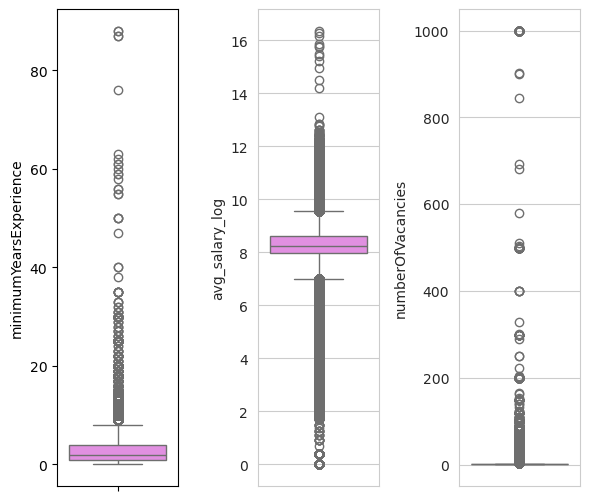

In [11]:
#4. Graphical Plot on targeted variables 
# --- There are questionable data inputs like > 80 years for min. years

# ---  Boxplot on selected features --- 
df1_box = df1[['minimumYearsExperience','avg_salary_log','numberOfVacancies']] 
l = df1_box.columns.values
total_plots = len(l)
no_cols=3
grid_rows = no_cols
plt.figure(figsize=(2*no_cols, 5*grid_rows))

for i in range (0,total_plots):
    plt.subplot(grid_rows, no_cols, i + 1)
    sns.set_style('whitegrid')
    sns.boxplot(df1[l[i]],color='violet',orient='v')
    plt.tight_layout()

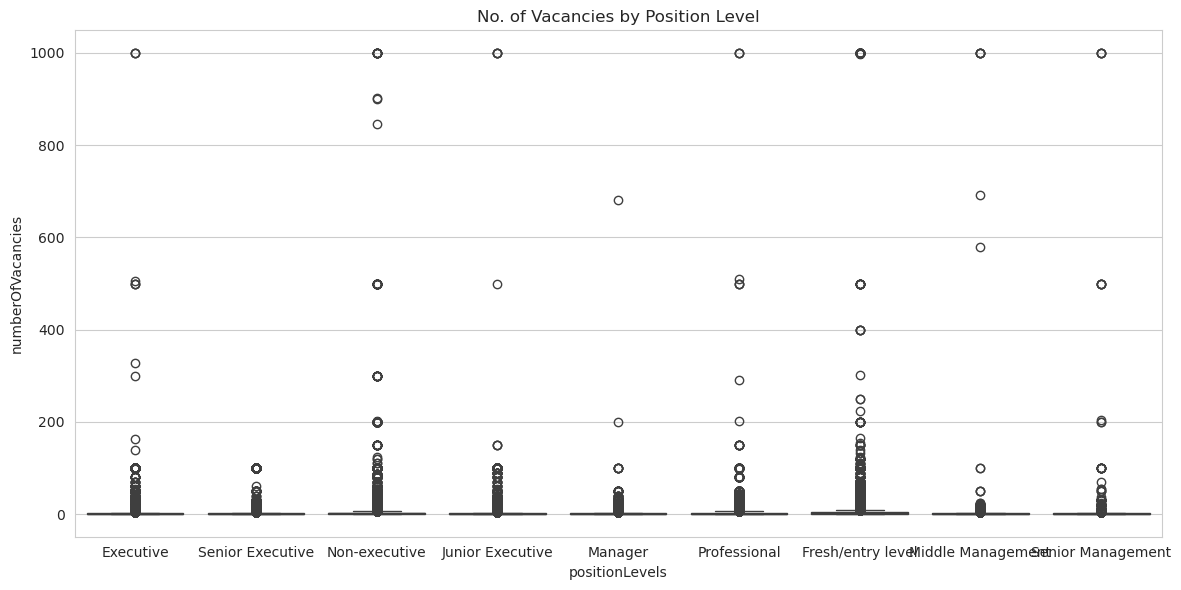

In [12]:
#4.2 Boxplot for No. of Vacancies by Position Levels 

plt.figure(figsize=(12,6))
plt.title('No. of Vacancies by Position Level')
sns.boxplot(x='positionLevels',y='numberOfVacancies',data=df1,showfliers=True)
plt.tight_layout()

In [13]:
# -- 1. Haircut for outliers 

df1['numberOfVacancies'] = pd.to_numeric(df1['numberOfVacancies'], errors='coerce')
upper_ceiling = df1['numberOfVacancies'] >= 99
outliers_Yr = df1[upper_ceiling]
print("Number of Outliers that are above upper ceiling:") 
display(outliers_Yr.shape)
total_vacancies_above_99 = outliers_Yr['numberOfVacancies'].sum()
print()
display(total_vacancies_above_99)

Number of Outliers that are above upper ceiling:


(2161, 22)

np.int64(325990)

In [14]:
df1=df1.drop(outliers_Yr.index,axis=0)
print(df1.shape)
print(f"Rows of outliers removed from df1: {len(outliers_Yr):,}.")

(1042436, 22)
Rows of outliers removed from df1: 2,161.


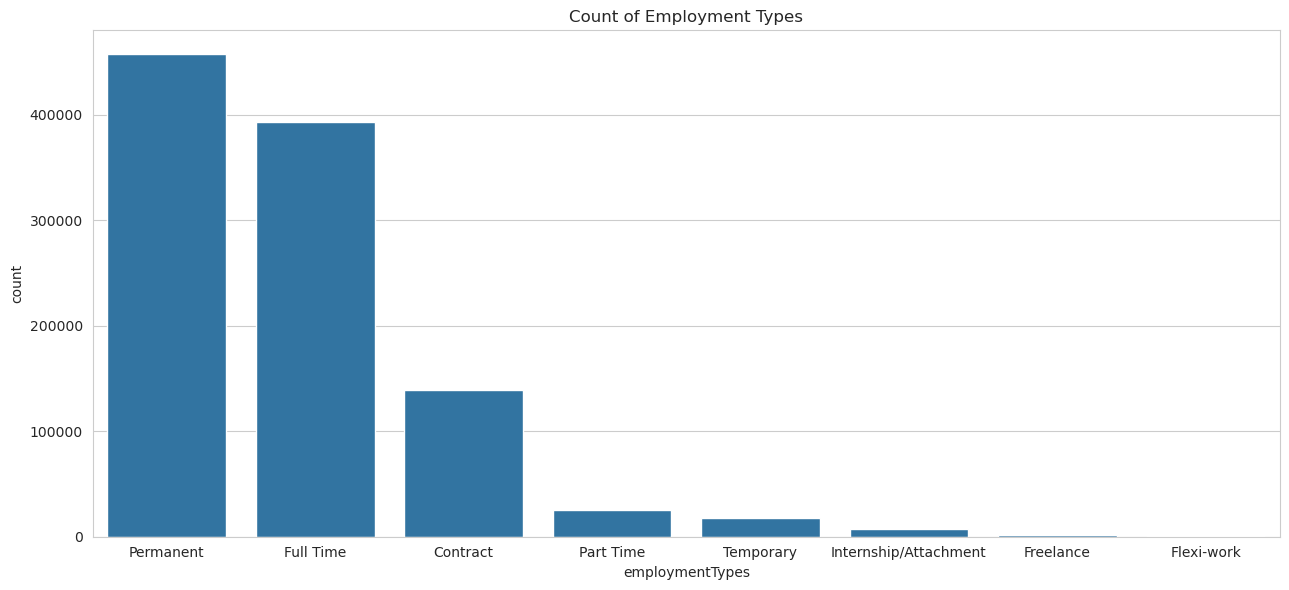

employmentTypes
Permanent                456897
Full Time                393018
Contract                 139026
Part Time                 25323
Temporary                 17987
Internship/Attachment      6956
Freelance                  2085
Flexi-work                 1144
Name: count, dtype: int64


In [15]:
plt.figure(figsize=(13,6))
# 2. Get the order (Descending)
#-- Cut from part time
desc_order = df1['employmentTypes'].value_counts().index

sns.countplot(x='employmentTypes', data=df1,order=desc_order)
plt.title('Count of Employment Types')
#plt.xticks()
plt.tight_layout()
plt.show()
status = df1['employmentTypes'].value_counts()
print(status)

In [16]:
#2. Drop  values from dataset 
# Create a list of target values
target_emp_lvl = ['Permanent', 'Full Time', 'Contract', 'Part Time']

df2 = df1[df1['employmentTypes'].isin(target_emp_lvl)]
print("===== Dataset with Targeted Employment levels =+===")
print()
print(df2['employmentTypes'].value_counts())
print()
print(f"Successfully saved {len(df2):,} rows to dataframe df2.")
print(f"Rows removed from df1: {1044597 - len(df2):,}.")

===== Dataset with Targeted Employment levels =+===

employmentTypes
Permanent    456897
Full Time    393018
Contract     139026
Part Time     25323
Name: count, dtype: int64

Successfully saved 1,014,264 rows to dataframe df2.
Rows removed from df1: 30,333.


In [17]:
#Remove unwanted Cols to reduce file size
df3 =df2 [['categories','positionLevels','status_jobStatus','title','numberOfVacancies']]
df3.head()
df3.info()


<class 'pandas.DataFrame'>
Index: 1014264 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   categories         1014264 non-null  str  
 1   positionLevels     1014264 non-null  str  
 2   status_jobStatus   1014264 non-null  str  
 3   title              1014264 non-null  str  
 4   numberOfVacancies  1014264 non-null  int64
dtypes: int64(1), str(4)
memory usage: 166.0 MB


## Preparation of Data for Dashboard below👇

In [18]:
# Grouping position levels into categories 
# 1. Entry & Support Level (Fresh/Entry Level, Non-Executive)
# 2. Professional & Individual Contributor (Junior Executive, Executive, Senior Executive, Professional)
# 3. Middle Management (Manager, Middle Management)
# 4. Senior Management (Senior Management)

position_categories = {
    'Fresh/entry level': 'Entry & Support Level',
    'Non-executive': 'Entry & Support Level',
    'Junior Executive': 'Professional & Individual Contributor',
    'Executive': 'Professional & Individual Contributor',
    'Senior Executive': 'Professional & Individual Contributor',
    'Professional': 'Professional & Individual Contributor',
    'Manager': 'Middle Management',
    'Middle Management': 'Middle Management',
    'Senior Management': 'Senior Management'
}
# Apply the mapping to create a new column 'position_category'
df3['position_category'] = df3['positionLevels'].map(position_categories)

df3.info()
df3['position_category'].value_counts()

<class 'pandas.DataFrame'>
Index: 1014264 entries, 0 to 1048574
Data columns (total 6 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   categories         1014264 non-null  str  
 1   positionLevels     1014264 non-null  str  
 2   status_jobStatus   1014264 non-null  str  
 3   title              1014264 non-null  str  
 4   numberOfVacancies  1014264 non-null  int64
 5   position_category  1014264 non-null  str  
dtypes: int64(1), str(5)
memory usage: 203.1 MB


position_category
Professional & Individual Contributor    624270
Entry & Support Level                    230565
Middle Management                        136697
Senior Management                         22732
Name: count, dtype: int64

In [19]:
df3['position_category'] = df3['position_category'].astype("category")
df3['status_jobStatus'] = df3['status_jobStatus'].astype("category")
df3["numberOfVacancies"] = df3["numberOfVacancies"].astype("int16")
df3.info()

<class 'pandas.DataFrame'>
Index: 1014264 entries, 0 to 1048574
Data columns (total 6 columns):
 #   Column             Non-Null Count    Dtype   
---  ------             --------------    -----   
 0   categories         1014264 non-null  str     
 1   positionLevels     1014264 non-null  str     
 2   status_jobStatus   1014264 non-null  category
 3   title              1014264 non-null  str     
 4   numberOfVacancies  1014264 non-null  int16   
 5   position_category  1014264 non-null  category
dtypes: category(2), int16(1), str(3)
memory usage: 150.1 MB


In [20]:
#Run this code to export to csv file for Dashboard Master Data
# Dashboard to include Filter for:
# 1) "status_jobStatus" = Default Open and Reopen
# 2) Job Category selection based on Top 5 items of cat_data['category'].value_counts() list
# df3.to_csv('output.csv', index=False)

df3.to_parquet("output_data.parquet", index=False)

### Stage 2 analysis of Categories using cleaned data

In [21]:
#Filter for Open and Reopen only

df3_open=df3[(df3['status_jobStatus'] == 'Open')|(df3['status_jobStatus'] == 'Re-open')]
#df3_open.info()


In [22]:
df3_open.info()

<class 'pandas.DataFrame'>
Index: 897835 entries, 84 to 1048574
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   categories         897835 non-null  str     
 1   positionLevels     897835 non-null  str     
 2   status_jobStatus   897835 non-null  category
 3   title              897835 non-null  str     
 4   numberOfVacancies  897835 non-null  int16   
 5   position_category  897835 non-null  category
dtypes: category(2), int16(1), str(3)
memory usage: 133.0 MB


In [23]:
# One line can have multiple job Categories, next step we analyse unique Job cateories and counts
category_list = df3_open['categories'].unique()
category_list

<ArrowStringArray>
[                                                                                                                                                                                                '[{"id":11,"category":"Engineering"}]',
                                                                                                '[{"id":2,"category":"Admin / Secretarial"},{"id":8,"category":"Customer Service"},{"id":18,"category":"Healthcare / Pharmaceutical"}]',
                                                                                                                                                   '[{"id":2,"category":"Admin / Secretarial"},{"id":8,"category":"Customer Service"}]',
                        '[{"id":7,"category":"Consulting"},{"id":8,"category":"Customer Service"},{"id":26,"category":"Marketing / Public Relations"},{"id":35,"category":"Sales / Retail"},{"id":39,"category":"Telecommunications"}]',
                                                 

In [24]:

# Analysis of unique job category/Ids in the dataset by parsing the JSON string 
# in the 'categories' column and creating a new DataFrame to analyze unique job categories and their counts.
# cat_data is the new dataframe with 1482638 lines (after splitting one line per category)
#There are 43 unique job category/Ids in the dataset
parsed_data = [item for sublist in df3_open['categories'] for item in json.loads(sublist)]
cat_data = pd.DataFrame(parsed_data)

unique_cat=cat_data[['id','category']].drop_duplicates()
display(unique_cat.sort_values(by='id'))
cat_data.info()

,id,category
29,1,Accounting / Auditing / Taxation
1,2,Admin / Secretarial
67,3,Advertising / Media
161,4,Architecture / Interior Design
185,5,Banking and Finance
30,6,Building and Construction
6,7,Consulting
2,8,Customer Service
69,9,Design
11,10,Education and Training


<class 'pandas.DataFrame'>
RangeIndex: 1518594 entries, 0 to 1518593
Data columns (total 2 columns):
 #   Column    Non-Null Count    Dtype
---  ------    --------------    -----
 0   id        1518594 non-null  int64
 1   category  1518594 non-null  str  
dtypes: int64(1), str(1)
memory usage: 48.8 MB


In [ ]:
cat_data_counts = cat_data['category'].value_counts().to_frame(name='count').reset_index()
cat_data_counts

,category,count
0,Information Technology,122754
1,Engineering,118538
2,Admin / Secretarial,98040
3,Customer Service,94283
4,Others,93768
5,Sales / Retail,90905
6,Building and Construction,74156
7,Accounting / Auditing / Taxation,66384
8,F&B,64344
9,Logistics / Supply Chain,59032


### Code to download cat_data_count table

In [ ]:
# code to download #unique_category with number of hits filtered by "Open and "Re-open"
cat_data_counts
cat_data_counts.to_csv('cat_data_count.csv', index=False) #-- can remove this if not needed for Streamlit dashboard

cat_data_counts.to_parquet("cat_data_counts.parquet", index=False)

### Stage 3 Analysis of Selected Job Category

In [27]:
df_job1 = df3_open[df3_open['categories'].str.contains('Information Technology')]

df_job1.head(10)

,categories,positionLevels,status_jobStatus,title,numberOfVacancies,position_category
1238,"[{""id"":11,""category"":""Engineering""},{""id"":21,""...",Junior Executive,Re-open,Project Engineer ( Plastic Injection ) Junior ...,2,Professional & Individual Contributor
1240,"[{""id"":11,""category"":""Engineering""},{""id"":21,""...",Junior Executive,Re-open,Mechanical Assistant Engineer / Associate Engi...,2,Professional & Individual Contributor
1245,"[{""id"":11,""category"":""Engineering""},{""id"":21,""...",Junior Executive,Re-open,IT Engineer ( Microsoft applications/infrastru...,2,Professional & Individual Contributor
1256,"[{""id"":11,""category"":""Engineering""},{""id"":21,""...",Junior Executive,Re-open,Engineering Specialist / Assistant Engineer (P...,2,Professional & Individual Contributor
1257,"[{""id"":11,""category"":""Engineering""},{""id"":21,""...",Junior Executive,Re-open,Engineering Assistant / Assembly Engineer ( 0-...,2,Professional & Individual Contributor
1260,"[{""id"":11,""category"":""Engineering""},{""id"":21,""...",Junior Executive,Re-open,Manufacturing / mechanical ( $2.5K - $4.5K ) (...,2,Professional & Individual Contributor
1264,"[{""id"":11,""category"":""Engineering""},{""id"":21,""...",Junior Executive,Re-open,Sales Application Engineer ( Valve Industry ),2,Professional & Individual Contributor
1312,"[{""id"":11,""category"":""Engineering""},{""id"":21,""...",Junior Executive,Re-open,MNC (Production / Manufacturing ) Assistant En...,2,Professional & Individual Contributor
1323,"[{""id"":11,""category"":""Engineering""},{""id"":21,""...",Junior Executive,Re-open,Commercial Controller / Senior Commercial Cont...,2,Professional & Individual Contributor
1577,"[{""id"":21,""category"":""Information Technology""}]",Executive,Re-open,Database Administrator,3,Professional & Individual Contributor


In [28]:
#Vacancy count by position levels for Customer Service Jobs

result = df_job1.groupby('positionLevels')['numberOfVacancies'].sum()
result

positionLevels
Executive            66809
Fresh/entry level    14484
Junior Executive     31534
Manager              18076
Middle Management     6277
Non-executive         7865
Professional         82110
Senior Executive     41307
Senior Management     3358
Name: numberOfVacancies, dtype: int64

In [29]:
#Vacancy count by position category for Information Technology Jobs

result2 = df_job1.groupby('position_category')['numberOfVacancies'].sum()
#sort result2 by total vacancies in descending order
result2.sort_values(ascending=False)


position_category
Professional & Individual Contributor    221760
Middle Management                         24353
Entry & Support Level                     22349
Senior Management                          3358
Name: numberOfVacancies, dtype: int64

In [30]:
df_job1.pivot_table(index=["position_category"], values=["numberOfVacancies"],aggfunc=sum)

,numberOfVacancies
position_category,
Entry & Support Level,22349
Middle Management,24353
Professional & Individual Contributor,221760
Senior Management,3358


In [31]:
df_job1.pivot_table(index=["position_category", "positionLevels"], values=["numberOfVacancies"],aggfunc=sum)

numberOfVacancies
position_category                     positionLevels                      
Entry & Support Level                 Fresh/entry level              14484
                                      Non-executive                   7865
Middle Management                     Manager                        18076
                                      Middle Management               6277
Professional & Individual Contributor Executive                      66809
                                      Junior Executive               31534
                                      Professional                   82110
                                      Senior Executive               41307
Senior Management                     Senior Management               3358